['image2', 'image1', 'image3']


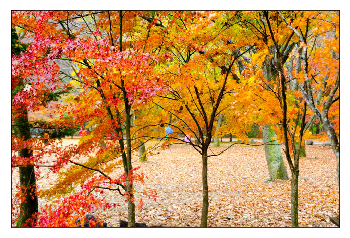

In [1]:
# Note: this requires the ``pillow`` package to be installed
from sklearn.datasets import load_sample_image
import matplotlib.pyplot as plt
import numpy as np 
import os
print(os.listdir('../input'))
# ####load image from sklearn.datasets 
# image = load_sample_image("china.jpg") # using image in sklearn.datasets 
# image = load_sample_image('flower.jpg')
#### using your own images // upload data using +Add Data
# image = plt.imread('..//input//image1//t3.JPG')
# image = plt.imread('..//input//image2//1801043_668936959839073_1438126562_n.jpg')
image = plt.imread('..//input//image3//1458973_620380134694756_880815135_n.jpg')


ax = plt.axes(xticks=[], yticks=[])
ax.imshow(image);

In [2]:
h, w, c = image.shape
print(image.shape)

(635, 960, 3)


In [3]:
data = image / 255.0 # use 0...1 scale
data = data.reshape((data.shape[0] * data.shape[1], 3))
data.shape

(609600, 3)

In [4]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data
    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    print(colors.shape)
    R, G, B = data[i].T
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

(10000, 3)


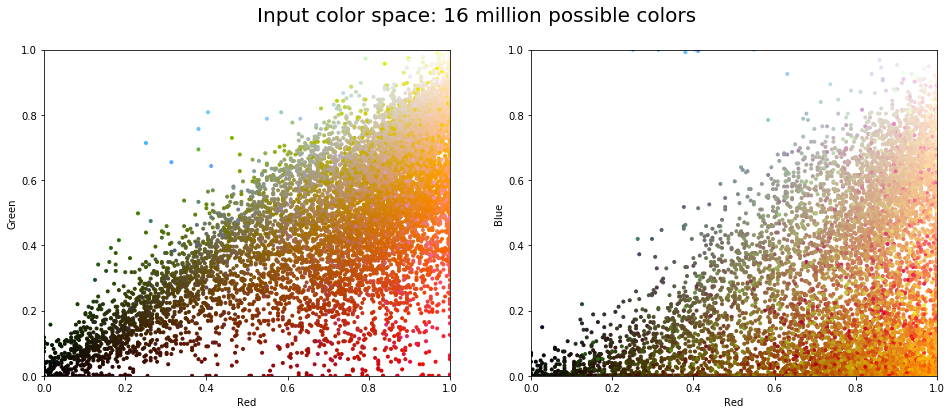

In [5]:
plot_pixels(data, title='Input color space: 16 million possible colors')


(10000, 3)


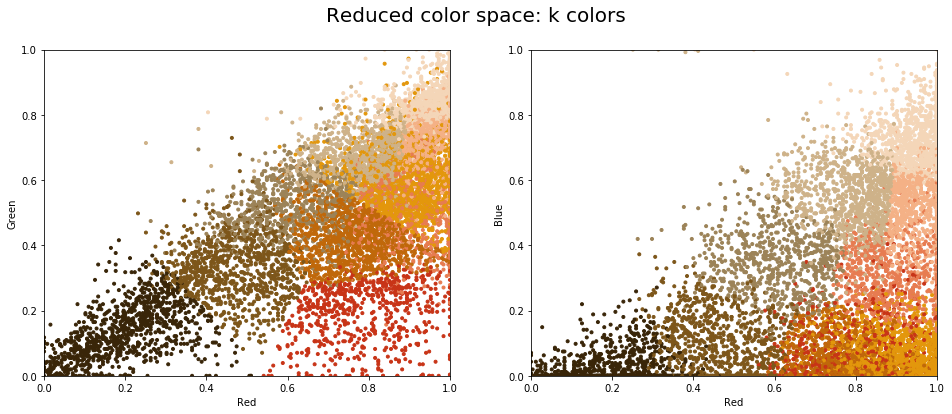

In [6]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(10)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,
            title="Reduced color space: k colors")

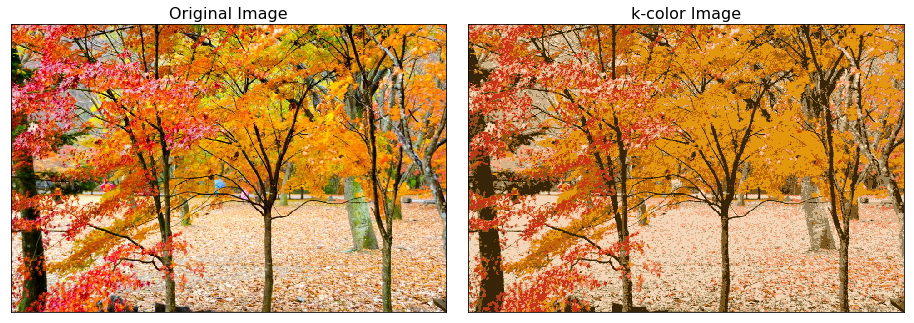

In [7]:
image_recolored = new_colors.reshape(image.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(image)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(image_recolored)
ax[1].set_title('k-color Image', size=16);